## Step 1 — Mount Google Drive & Install Dependencies

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted successfully.')

Mounted at /content/drive
Drive mounted successfully.


In [ ]:
!pip install ultralytics --quiet
print('ultralytics installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.1 MB/s eta 0:00:00
ultralytics installed.


## Step 2 — Imports & Constants

In [ ]:
import os
import shutil
import random
import xml.etree.ElementTree as ET
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.cm as cm
import seaborn as sns
from PIL import Image
from pathlib import Path
from collections import defaultdict
import cv2
import yaml
from ultralytics import YOLO
import torch

DATASET_PATH   = '/content/drive/MyDrive/Manufacturing Surface Anomaly Inspector/'
IMAGES_PATH    = os.path.join(DATASET_PATH, 'images/')
YOLO_DS_PATH   = os.path.join(DATASET_PATH, 'yolov8_dataset/')
RUNS_SAVE_PATH = os.path.join(DATASET_PATH, 'runs/')

RAW_TO_ENGLISH = {
    '9_zhehen'   : 'crease',
    '3_yueyawan' : 'crescent_gap',
    '7_yiwu'     : 'inclusion',
    '5_youban'   : 'oil_spot',
    '1_chongkong': 'punching_hole',
    '10_yaozhe'  : 'rolled_pit',
    '6_siban'    : 'silk_spot',
    '10_yaozhed' : 'waist_folding',
    '4_shuiban'  : 'water_spot',
    '2_hanfeng'  : 'welding_line',
    # Excluded classes (not in our 10-class plan):
    # '8_yahen'  : 'scratch'   — only 83 samples, not in scope
    # 'd'        : 'unknown'   — corrupt/mislabelled, 1 sample
}

CLASS_NAMES = sorted(set(RAW_TO_ENGLISH.values()))
CLASS_TO_ID = {name: i for i, name in enumerate(CLASS_NAMES)}
NUM_CLASSES = len(CLASS_NAMES)

IMG_EXTS = ('.jpg', '.jpeg', '.png', '.bmp')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
print(f'GPU             : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')
print(f'\nNum classes     : {NUM_CLASSES}')
print(f'Class → ID      : {CLASS_TO_ID}')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU             : Tesla T4

Num classes     : 10
Class → ID      : {'crease': 0, 'crescent_gap': 1, 'inclusion': 2, 'oil_spot': 3, 'punching_hole': 4, 'rolled_pit': 5, 'silk_spot': 6, 'waist_folding': 7, 'water_spot': 8, 'welding_line': 9}


## Step 3 — Parse XML Annotations (Pascal VOC → DataFrame)

In [ ]:
def find_all_xmls(root_dir):
    """Recursively find all XML files under root_dir."""
    xml_files = []
    for dirpath, _, filenames in os.walk(root_dir):
        for f in filenames:
            if f.endswith('.xml'):
                xml_files.append(os.path.join(dirpath, f))
    return xml_files


def parse_voc_xml(xml_path):
    """Parse a single Pascal VOC XML file.
    Returns list of dicts: {image_filename, class_raw, class_name, xmin, ymin, xmax, ymax, img_w, img_h}
    Skips objects whose raw class name is not in RAW_TO_ENGLISH.
    """
    records = []
    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()

        filename_el = root.find('filename')
        image_filename = filename_el.text.strip() if filename_el is not None else None

        size_el = root.find('size')
        if size_el is not None:
            img_w = int(size_el.find('width').text)
            img_h = int(size_el.find('height').text)
        else:
            img_w, img_h = None, None

        for obj in root.findall('object'):
            name_el = obj.find('name')
            if name_el is None:
                continue
            class_raw = name_el.text.strip()

            # Skip classes not in our mapping (scratch, unknown, etc.)
            if class_raw not in RAW_TO_ENGLISH:
                continue

            class_name = RAW_TO_ENGLISH[class_raw]

            bbox = obj.find('bndbox')
            if bbox is None:
                continue

            xmin = int(float(bbox.find('xmin').text))
            ymin = int(float(bbox.find('ymin').text))
            xmax = int(float(bbox.find('xmax').text))
            ymax = int(float(bbox.find('ymax').text))

            if xmax <= xmin or ymax <= ymin:
                continue

            records.append({
                'image_filename': image_filename,
                'class_raw'     : class_raw,
                'class_name'    : class_name,
                'class_id'      : CLASS_TO_ID[class_name],
                'xmin': xmin, 'ymin': ymin,
                'xmax': xmax, 'ymax': ymax,
                'img_w': img_w, 'img_h': img_h,
            })
    except Exception as e:
        print(f'  [WARN] Could not parse {xml_path}: {e}')
    return records


print('Searching for XML annotation files...')
xml_files = find_all_xmls(DATASET_PATH)
# Exclude any XMLs that may be inside the yolov8_dataset folder from a previous run
xml_files = [f for f in xml_files if 'yolov8_dataset' not in f]
print(f'Found {len(xml_files)} XML files.')

all_records = []
for xf in xml_files:
    all_records.extend(parse_voc_xml(xf))

df = pd.DataFrame(all_records)
print(f'\nTotal annotations (10 classes only): {len(df)}')
print(f'Unique images with annotations     : {df["image_filename"].nunique()}')
print(f'\nClass distribution:')
print(df['class_name'].value_counts().to_string())

Searching for XML annotation files...
Found 2288 XML files.

Total annotations (10 classes only): 3466
Unique images with annotations     : 2249

Class distribution:
class_name
silk_spot        892
oil_spot         569
welding_line     506
water_spot       352
inclusion        344
punching_hole    324
crescent_gap     263
waist_folding    131
crease            74
rolled_pit        11


In [ ]:
print('Building image path map...')
images_to_path = {}
for dirpath, _, files in os.walk(IMAGES_PATH):
    for f in files:
        if f.lower().endswith(IMG_EXTS):
            images_to_path[f] = os.path.join(dirpath, f)

print(f'Total images found on disk: {len(images_to_path)}')


annotated_images = df['image_filename'].unique()
found   = [fn for fn in annotated_images if fn in images_to_path]
missing = [fn for fn in annotated_images if fn not in images_to_path]
print(f'Annotated images found on disk : {len(found)}')
if missing:
    print(f'[WARN] Missing from disk       : {len(missing)}')
    print('  First 5:', missing[:5])

Building image path map...
Total images found on disk: 2296
Annotated images found on disk : 2249


## Step 4 — Exploratory Data Analysis (EDA)

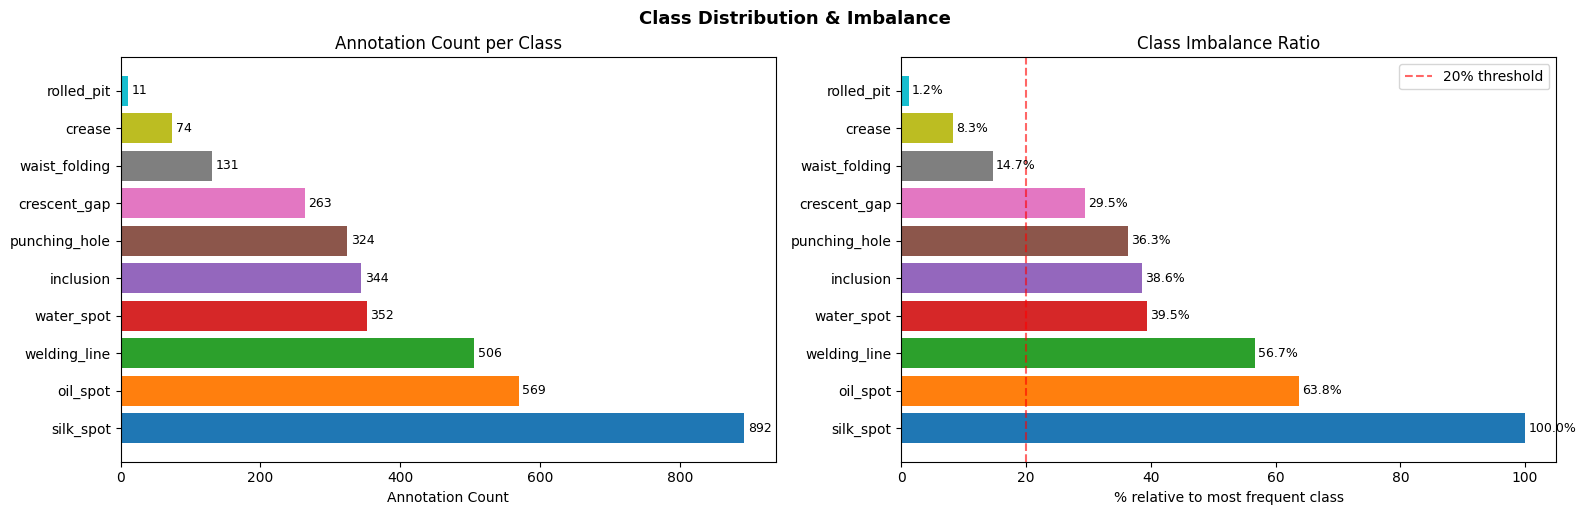


[KEY INSIGHT] Severe imbalance:
  Most frequent : silk_spot (892 samples)
  Least frequent: rolled_pit (11 samples)
  Imbalance ratio: 81.1x


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

counts = df['class_name'].value_counts()
colors = cm.tab10(np.linspace(0, 1, len(counts)))
axes[0].barh(counts.index, counts.values, color=colors)
axes[0].set_xlabel('Annotation Count')
axes[0].set_title('Annotation Count per Class')
for i, v in enumerate(counts.values):
    axes[0].text(v + 5, i, str(v), va='center', fontsize=9)


max_count = counts.max()
ratio = counts / max_count * 100
axes[1].barh(ratio.index, ratio.values, color=colors)
axes[1].set_xlabel('% relative to most frequent class')
axes[1].set_title('Class Imbalance Ratio')
axes[1].axvline(x=20, color='red', linestyle='--', alpha=0.6, label='20% threshold')
axes[1].legend()
for i, v in enumerate(ratio.values):
    axes[1].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.suptitle('Class Distribution & Imbalance', y=1.02, fontsize=13, fontweight='bold')
plt.show()
print('\n[KEY INSIGHT] Severe imbalance:')
print(f'  Most frequent : {counts.idxmax()} ({counts.max()} samples)')
print(f'  Least frequent: {counts.idxmin()} ({counts.min()} samples)')
print(f'  Imbalance ratio: {counts.max()/counts.min():.1f}x')

BBox Statistics:
       bbox_w  bbox_h  bbox_area  aspect_ratio
count  3466.0  3466.0     3466.0        3466.0
mean    492.1   321.8   157231.3           4.2
std     586.1   301.3   235664.9           8.5
min      14.0    16.0      576.0           0.1
25%     115.0    72.0    10741.5           0.6
50%     247.5   193.5    72960.0           1.0
75%     561.8   535.8   178437.8           1.9
max    2047.0   999.0  1704220.0          67.5


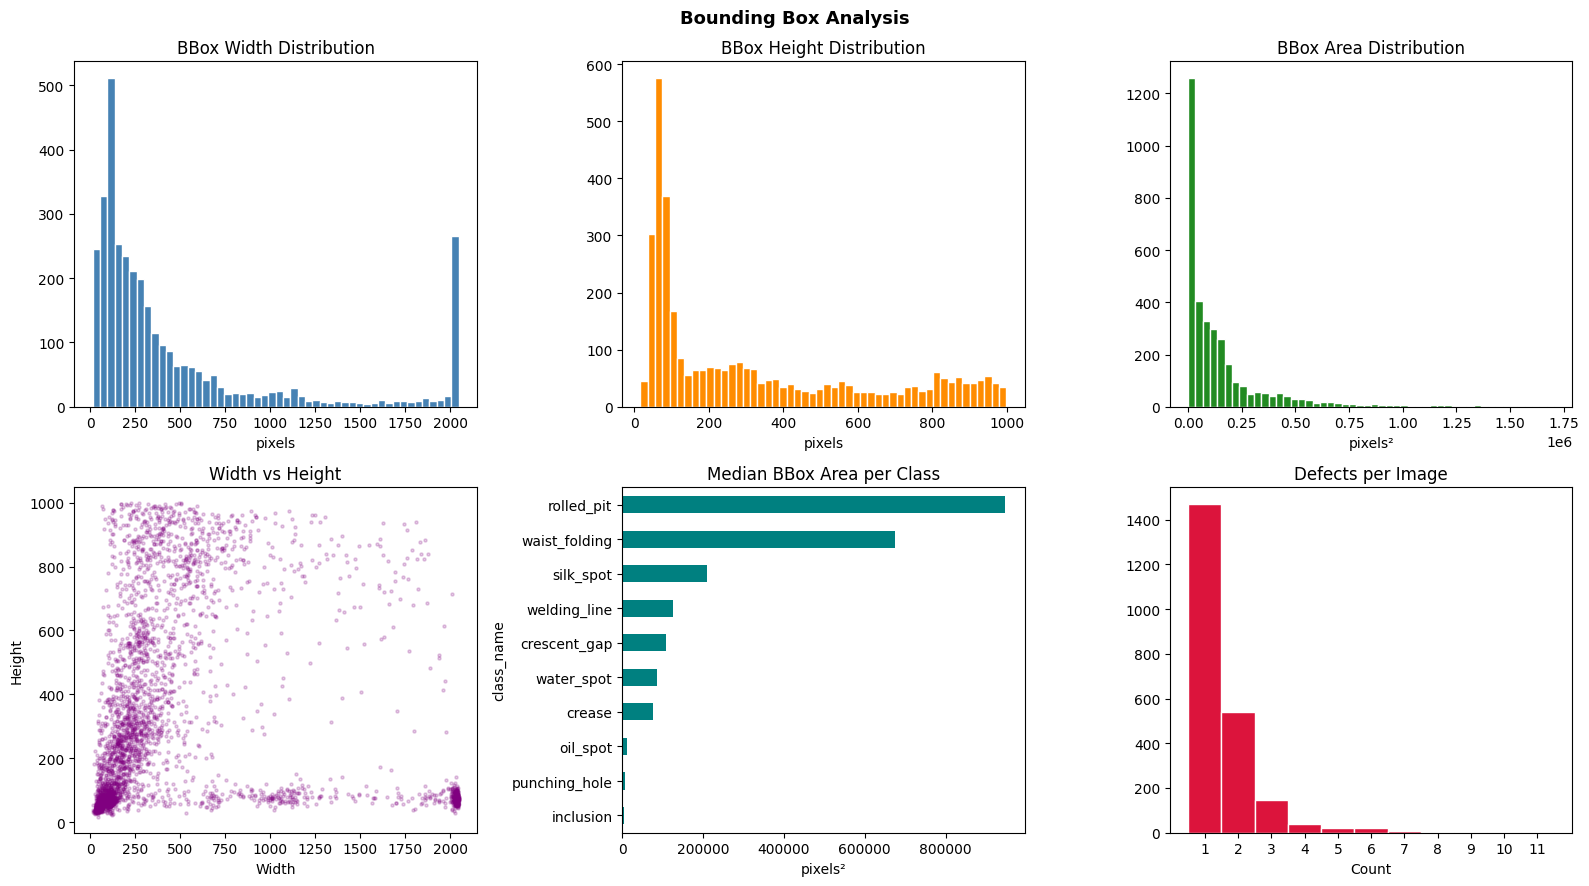


Average defects per image: 1.54
Max defects in one image : 11


In [ ]:
df['bbox_w'] = df['xmax'] - df['xmin']
df['bbox_h'] = df['ymax'] - df['ymin']
df['bbox_area'] = df['bbox_w'] * df['bbox_h']
df['aspect_ratio'] = df['bbox_w'] / df['bbox_h'].replace(0, np.nan)

# Normalised (relative to image size where available)
df['norm_w'] = np.where(df['img_w'].notna(), df['bbox_w'] / df['img_w'], np.nan)
df['norm_h'] = np.where(df['img_h'].notna(), df['bbox_h'] / df['img_h'], np.nan)

print('BBox Statistics:')
print(df[['bbox_w','bbox_h','bbox_area','aspect_ratio']].describe().round(1).to_string())

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Bounding Box Analysis', fontsize=13, fontweight='bold')

axes[0,0].hist(df['bbox_w'], bins=50, color='steelblue', edgecolor='white')
axes[0,0].set_title('BBox Width Distribution'); axes[0,0].set_xlabel('pixels')

axes[0,1].hist(df['bbox_h'], bins=50, color='darkorange', edgecolor='white')
axes[0,1].set_title('BBox Height Distribution'); axes[0,1].set_xlabel('pixels')

axes[0,2].hist(df['bbox_area'], bins=50, color='forestgreen', edgecolor='white')
axes[0,2].set_title('BBox Area Distribution'); axes[0,2].set_xlabel('pixels²')

axes[1,0].scatter(df['bbox_w'], df['bbox_h'], alpha=0.2, s=5, c='purple')
axes[1,0].set_title('Width vs Height'); axes[1,0].set_xlabel('Width'); axes[1,0].set_ylabel('Height')

# Per-class median bbox area
per_class_area = df.groupby('class_name')['bbox_area'].median().sort_values()
per_class_area.plot(kind='barh', ax=axes[1,1], color='teal')
axes[1,1].set_title('Median BBox Area per Class'); axes[1,1].set_xlabel('pixels²')

# Defects per image histogram
defects_per_img = df.groupby('image_filename').size()
axes[1,2].hist(defects_per_img, bins=range(1, defects_per_img.max()+2),
               color='crimson', edgecolor='white', align='left')
axes[1,2].set_title('Defects per Image'); axes[1,2].set_xlabel('Count')
axes[1,2].set_xticks(range(1, min(defects_per_img.max()+1, 15)))

plt.tight_layout()
plt.show()
print(f'\nAverage defects per image: {defects_per_img.mean():.2f}')
print(f'Max defects in one image : {defects_per_img.max()}')

Visualizing 2 sample images per class with bounding boxes...


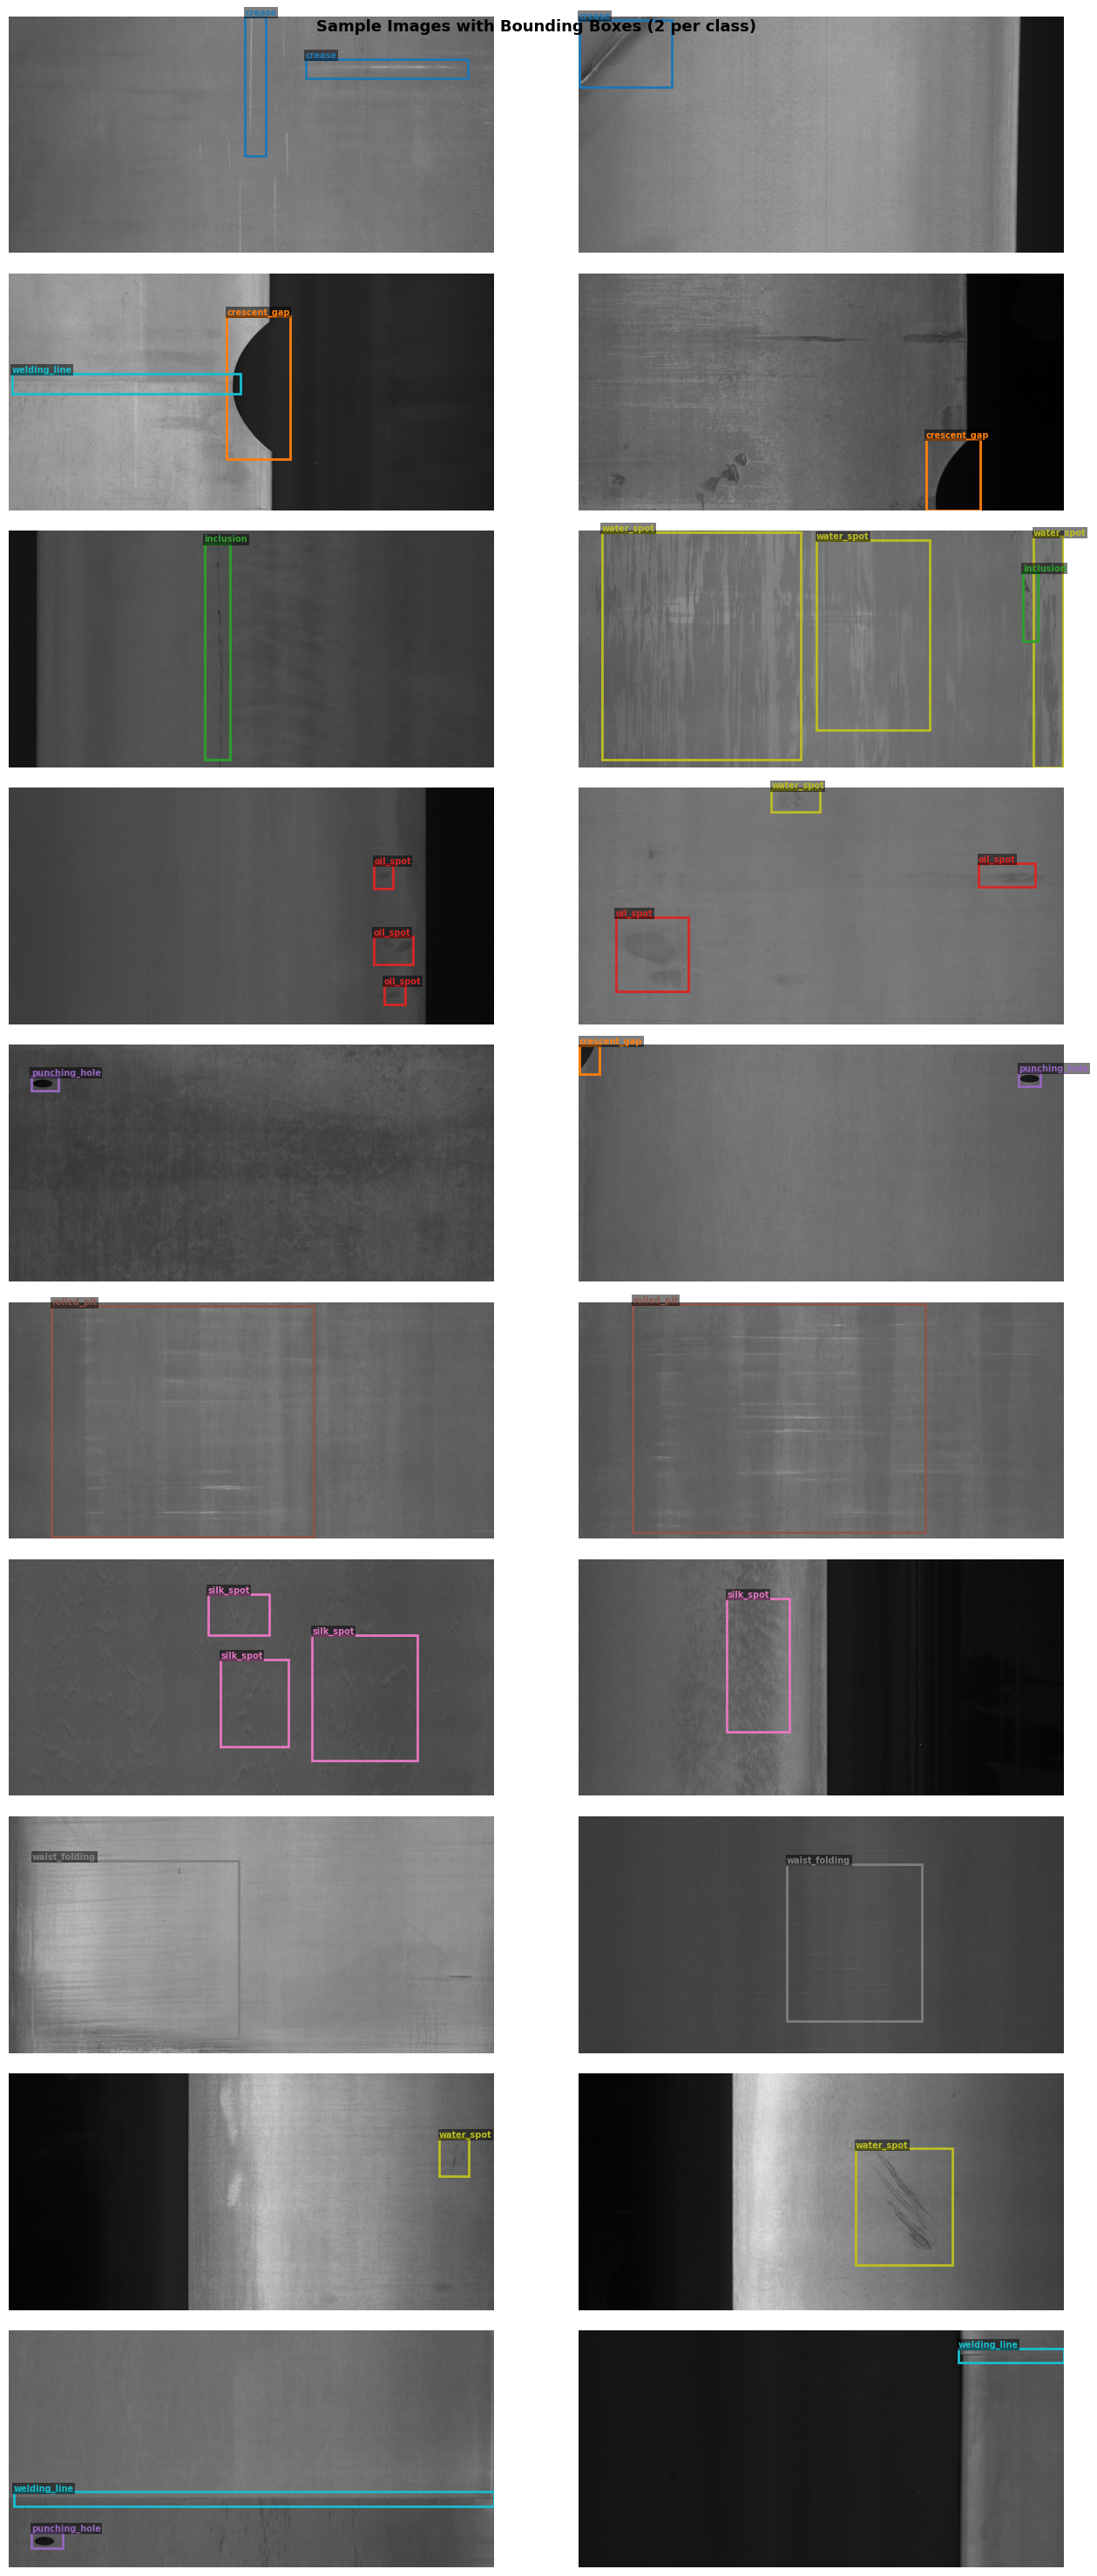

In [ ]:
print('Visualizing 2 sample images per class with bounding boxes...')

CLASS_COLORS = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))
color_map = {name: CLASS_COLORS[i] for i, name in enumerate(CLASS_NAMES)}

fig, axes = plt.subplots(NUM_CLASSES, 2, figsize=(14, NUM_CLASSES * 3))
fig.suptitle('Sample Images with Bounding Boxes (2 per class)', fontsize=13, fontweight='bold')

for row_idx, class_name in enumerate(CLASS_NAMES):
    class_df = df[df['class_name'] == class_name]
    unique_imgs = class_df['image_filename'].unique()
    sample_imgs = np.random.choice(unique_imgs, min(2, len(unique_imgs)), replace=False)

    for col_idx, img_fn in enumerate(sample_imgs):
        ax = axes[row_idx][col_idx]
        img_path = images_to_path.get(img_fn)

        if img_path and os.path.exists(img_path):
            img = Image.open(img_path).convert('RGB')
            ax.imshow(img, cmap='gray')
            img_anns = df[df['image_filename'] == img_fn]
            for _, ann in img_anns.iterrows():
                c = color_map.get(ann['class_name'], (1,0,0,1))
                rect = patches.Rectangle(
                    (ann['xmin'], ann['ymin']),
                    ann['xmax']-ann['xmin'], ann['ymax']-ann['ymin'],
                    linewidth=2, edgecolor=c, facecolor='none'
                )
                ax.add_patch(rect)
                ax.text(ann['xmin'], ann['ymin']-5, ann['class_name'],
                        color=c, fontsize=7, fontweight='bold',
                        bbox=dict(facecolor='black', alpha=0.5, pad=1, edgecolor='none'))
        else:
            ax.text(0.5, 0.5, 'Image not found', ha='center', va='center', transform=ax.transAxes)
            ax.set_facecolor('#333')

        if col_idx == 0:
            ax.set_ylabel(class_name, fontsize=9, fontweight='bold', rotation=90)
        ax.axis('off')

    if len(sample_imgs) < 2:
        axes[row_idx][1].axis('off')

plt.tight_layout()
plt.show()